In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('Summary of Weather.csv', low_memory=False)

In [3]:
df = df[['Precip', 'MaxTemp', 'MinTemp']]

In [4]:
df.nunique()

Precip     540
MaxTemp    149
MinTemp    132
dtype: int64

In [5]:
df.shape

(119040, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Precip   119040 non-null  object 
 1   MaxTemp  119040 non-null  float64
 2   MinTemp  119040 non-null  float64
dtypes: float64(2), object(1)
memory usage: 2.7+ MB


In [7]:
df['MinTemp'].isnull().sum()

np.int64(0)

In [8]:
X = df[['MaxTemp']]
y = df['MinTemp']

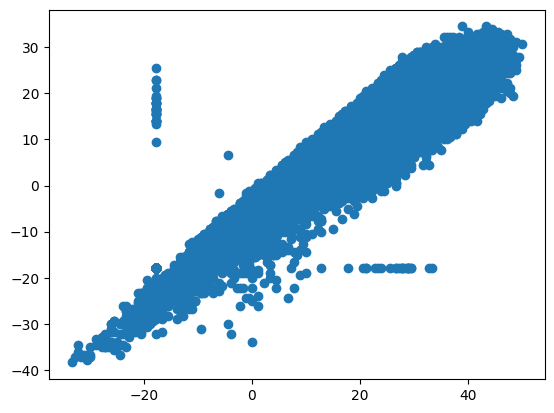

In [9]:
plt.scatter(X['MaxTemp'], y)
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 42, test_size = 0.2)

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((95232, 1), (23808, 1), (95232,), (23808,))

In [12]:
print(y_train)

84900     13.888889
35602     21.111111
102042    22.777778
106381    25.000000
19132     22.777778
            ...    
76820     18.333333
110268    23.888889
103694    24.444444
860       23.333333
15795     22.222222
Name: MinTemp, Length: 95232, dtype: float64


In [13]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = lr.predict(X_test)

In [15]:
r2_score(y_pred, y_test)*100

70.39570474683136

In [16]:
print(lr.intercept_)
print(lr.coef_)

-4.90962028186506
[0.83949208]


## Now Gradient Descent approach

In [47]:
# class GDRegressor:

#     def __init__(self, learning_rate, epochs):
#         self.m = 0
#         self.b = 0
#         self.lr = learning_rate
#         self.epochs = epochs

#     def fit(self, X,y):


#         X = X.to_numpy().ravel()
#         y = y.to_numpy().ravel()
#         for i in range(self.epochs):

#             loss_slope_b = -2 * np.sum(y - self.m*X - self.b)
#             loss_slope_m = -2 * np.sum((y - self.m*X - self.b)*X)

#             self.b = self.b - (self.lr * loss_slope_b)
#             self.m = self.m - (self.lr * loss_slope_m)

#         print(self.m, self.b)

#     def predict(self, X):
#         X = X.to_numpy().ravel()
#         return self.m*X + self.b

In [48]:
class GDRegressor:

    def __init__(self, learning_rate, epochs):
        self.m = 0
        self.b = 0
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):

        X = X.to_numpy().ravel()
        y = y.to_numpy().ravel()

        for i in range(self.epochs):

            y_pred = self.m * X + self.b

            loss_slope_b = -2 * np.mean(y - y_pred)

            loss_slope_m = -2 * np.mean((y - y_pred) * X)

            self.b = self.b - self.lr * loss_slope_b
            self.m = self.m - self.lr * loss_slope_m

        print("m =", self.m)
        print("b =", self.b)

    def predict(self, X):

        X = X.to_numpy().ravel()

        return self.m * X + self.b

In [78]:
gd = GDRegressor(0.001, 80)

In [79]:
gd.fit(X_train, y_train)

m = 0.6766714353642175
b = -0.05136028566747719


In [80]:
print("m =", gd.m)
print("b =", gd.b)

m = 0.6766714353642175
b = -0.05136028566747719


In [81]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)*100

73.95969869398185

In [46]:
print(X_train.min())
print(X_train.max())
print(y_train.min())
print(y_train.max())

MaxTemp   -33.333333
dtype: float64
MaxTemp    50.0
dtype: float64
-38.33333333
34.44444444
